In [1]:
!free -h

              total        used        free      shared  buff/cache   available
Mem:          251Gi        30Gi       166Gi        29Gi        55Gi       189Gi
Swap:            0B          0B          0B


In [2]:
import os
import shutil
import gzip
import zipfile
import time
import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from scipy.signal import welch
from scipy.signal import butter, filtfilt

In [3]:
import os

folder_path = '/scratch/besp/shared_data/capture24'  # replace with your actual folder path

# Count number of files (excluding subfolders)
num_files = sum(1 for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)))

print(f"Number of files in '{folder_path}': {num_files}")

Number of files in '/scratch/besp/shared_data/capture24': 3


In [4]:
print("Current directory:", os.getcwd())

Current directory: /u/sarahhjiang


In [5]:
df = pd.read_csv('/scratch/besp/shared_data/capture24/metadata.csv')
df.head()

,pid,age,sex
0,P001,38-52,F
1,P002,30-37,F
2,P003,30-37,F
3,P004,53+,F
4,P005,38-52,F


In [6]:
# with zipfile.ZipFile('capture24/capture24_parquets.zip', 'r') as zip_ref:
#     zip_ref.extractall('capture24')

In [20]:
parquet_folder = '/scratch/besp/shared_data/capture24/processed'

# List all .parquet files
parquet_files = [f for f in os.listdir(parquet_folder) if f.endswith('.parquet')]

print(len(parquet_files))

18


In [23]:
file_path = os.path.join(parquet_folder, 'P010_start_20161215T020400_10Hz.parquet')
print(f"{file_path} size: {os.path.getsize(file_path) / 1024:.2f} KB")

/scratch/besp/shared_data/capture24/processed/P010_start_20161215T020400_10Hz.parquet size: 3198.14 KB


In [24]:
start = time.time()
ddf = dd.read_parquet(file_path)
end = time.time()

print(f"Read time: {end - start:.2f} seconds")

Read time: 0.01 seconds


In [25]:
ddf = dd.read_parquet(file_path)
ddf.head()

,x,y,z,activity,MET
0,0.764001,-0.38923,-0.501527,sleeping,0.95
1,0.764001,-0.38923,-0.517579,sleeping,0.95
2,0.764001,-0.38923,-0.517579,sleeping,0.95
3,0.764001,-0.38923,-0.501527,sleeping,0.95
4,0.764001,-0.38923,-0.501527,sleeping,0.95


In [26]:
ddf.shape[0].compute()

918001

In [27]:
ddf.dtypes

x           float64
y           float64
z           float64
activity     object
MET         float64
dtype: object

In [13]:
# Split annotation column into parts
ddf[['activity_id', 'activity_raw']] = ddf['annotation'].str.extract(r'(\d+)\s+(.*)', expand=True)
ddf['activity'] = ddf['activity_raw'].str.extract(r'([a-zA-Z\s]+)', expand=False).str.strip()
ddf['MET'] = ddf['activity_raw'].str.extract(r'MET\s+([0-9.]+)', expand=False).astype(float)

In [14]:
ddf['time'] = dd.to_datetime(ddf['time'])

In [15]:
ddf_subsampled = ddf.map_partitions(lambda df: df.iloc[::100])
ddf_subsampled.shape[0].compute()

88279

In [16]:
pdf = ddf_subsampled.compute()

In [17]:
pdf.head()

,time,x,y,z,annotation,activity_id,activity_raw,activity,MET
0,2016-10-21 00:56:00,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
100,2016-10-21 00:56:01,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
200,2016-10-21 00:56:02,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
300,2016-10-21 00:56:03,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
400,2016-10-21 00:56:04,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95


In [18]:
pdf[:]

,time,x,y,z,annotation,activity_id,activity_raw,activity,MET
0,2016-10-21 00:56:00,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
100,2016-10-21 00:56:01,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
200,2016-10-21 00:56:02,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
300,2016-10-21 00:56:03,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
400,2016-10-21 00:56:04,0.142183,0.241858,0.948204,7030 sleeping;MET 0.95,7030,sleeping;MET 0.95,sleeping,0.95
...,...,...,...,...,...,...,...,...,...
8827400,2016-10-22 01:27:14,-0.154196,-0.995765,0.069468,None,NaN,NaN,NaN,NaN
8827500,2016-10-22 01:27:15,-0.154196,-0.995765,0.069468,None,NaN,NaN,NaN,NaN
8827600,2016-10-22 01:27:16,-0.138584,-0.979897,0.085448,None,NaN,NaN,NaN,NaN
8827700,2016-10-22 01:27:17,-0.138584,-0.979897,0.085448,None,NaN,NaN,NaN,NaN


In [19]:
pdf.dtypes

time            datetime64[ns]
x                      float64
y                      float64
z                      float64
annotation              object
activity_id             object
activity_raw            object
activity                object
MET                    float64
dtype: object

In [20]:
accel_data = pdf[['x', 'y', 'z']].T  # shape: (3, time_steps)
accel_data.columns = pdf['time'].dt.strftime('%H:%M:%S.%f').str[:]  # format time to HH:MM:SS.sss

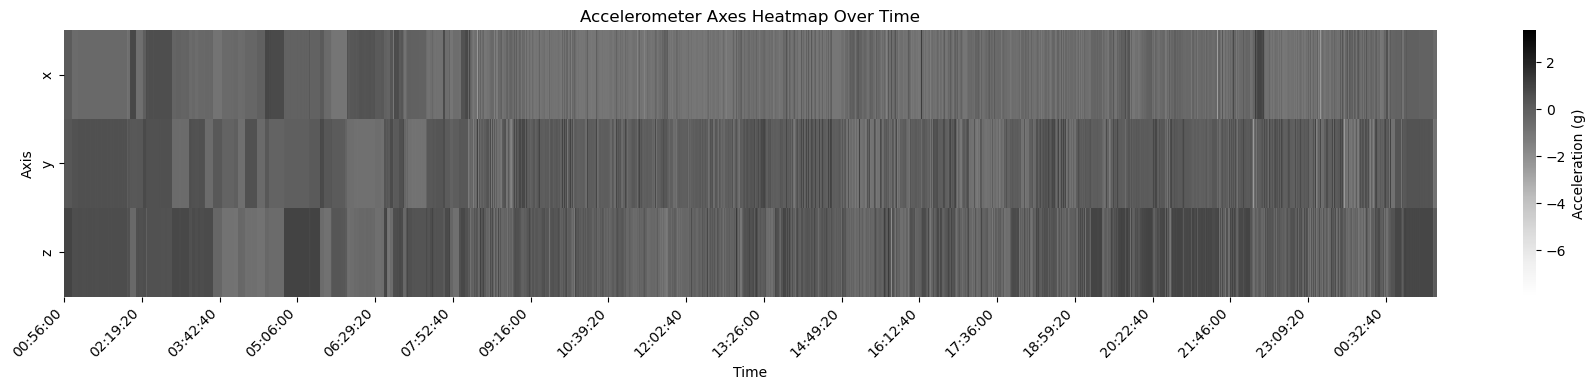

In [21]:
accel_data.columns = pd.to_datetime(accel_data.columns, format='%H:%M:%S.%f')

plt.figure(figsize=(18, 4))
sns.heatmap(accel_data, cmap='Greys', cbar_kws={'label': 'Acceleration (g)'})
plt.title("Accelerometer Axes Heatmap Over Time")
plt.xlabel("Time")
plt.ylabel("Axis")

xticks = np.arange(0, accel_data.shape[1], 5000)
xtick_labels = accel_data.columns[xticks].strftime('%H:%M:%S')  # Clean format

plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

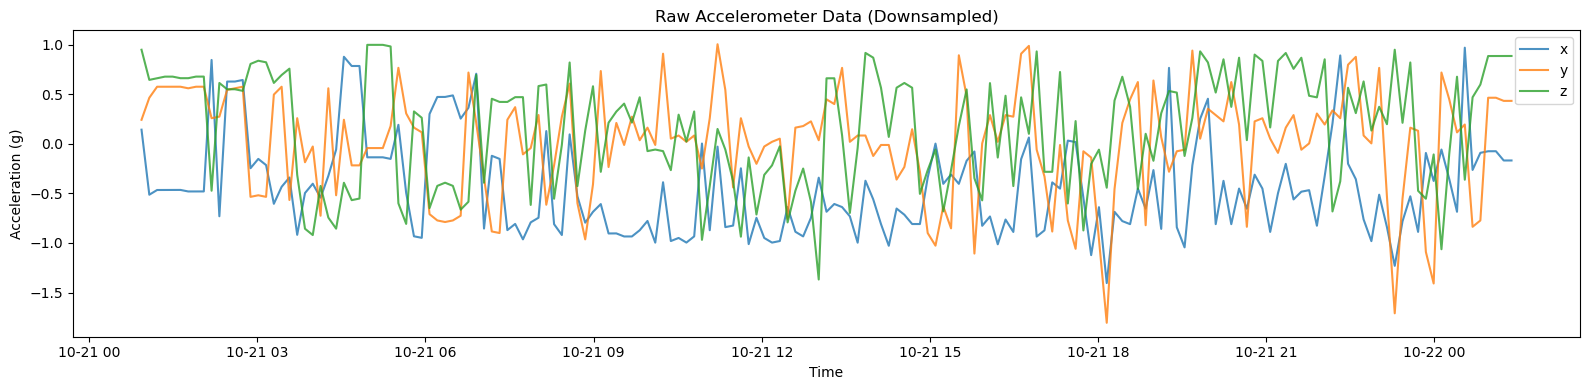

In [22]:
pdf_sampled = pdf.iloc[::500]  # downsample for speed

plt.figure(figsize=(16, 4))
for axis in ['x', 'y', 'z']:
    plt.plot(pdf_sampled['time'], pdf_sampled[axis], label=axis, alpha=0.8)

plt.title('Raw Accelerometer Data (Downsampled)')
plt.xlabel('Time')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.tight_layout()
plt.show()

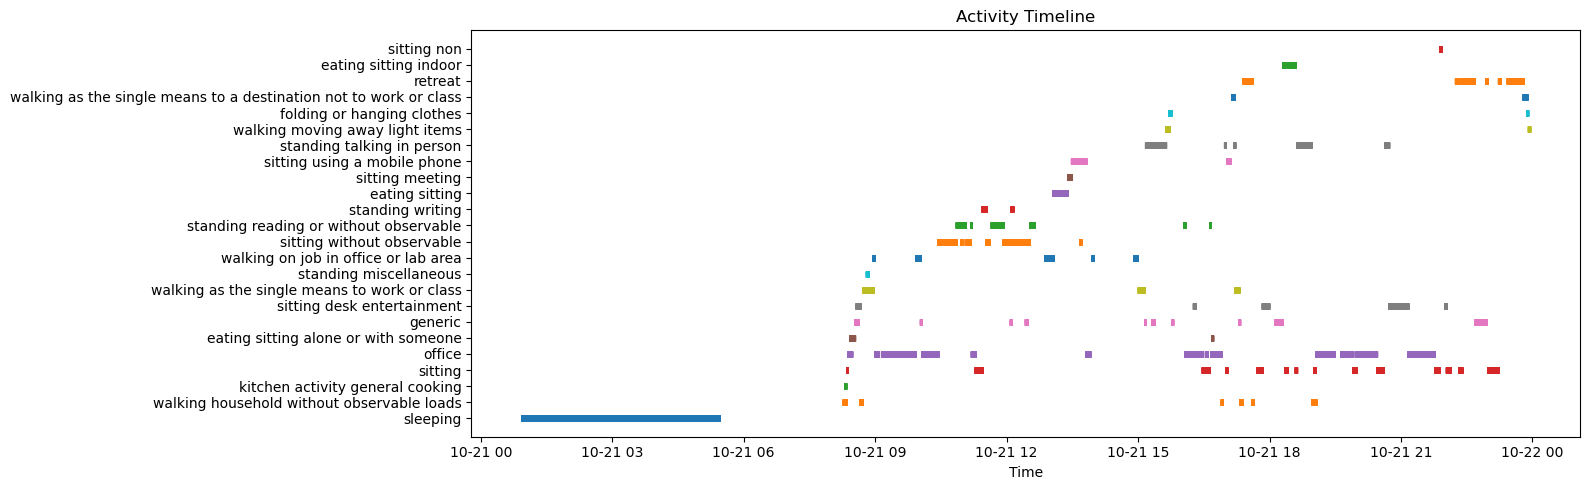

In [23]:
# First, encode activities as categorical integers
activity_map = {label: i for i, label in enumerate(pdf['activity'].dropna().unique())}
pdf['activity_code'] = pdf['activity'].map(activity_map)

# Plot a horizontal bar timeline
plt.figure(figsize=(16, 5))
for activity, code in activity_map.items():
    activity_times = pdf[pdf['activity'] == activity]['time']
    if activity_times.empty:
        continue
    plt.plot(activity_times, [code]*len(activity_times), '|', label=activity, markersize=4)

plt.yticks(list(activity_map.values()), list(activity_map.keys()))
plt.xlabel("Time")
plt.title("Activity Timeline")
plt.tight_layout()
plt.show()

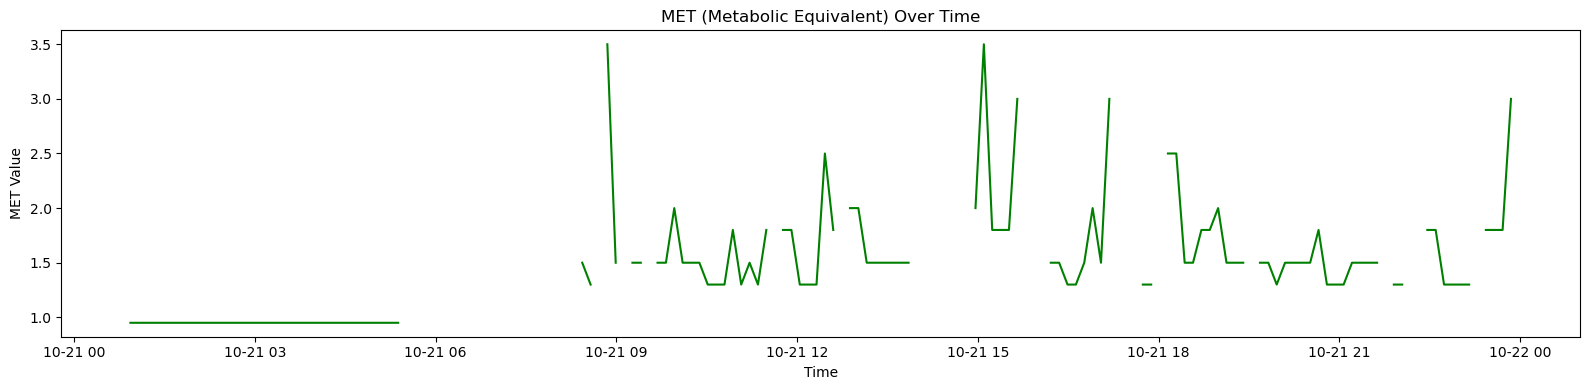

In [24]:
plt.figure(figsize=(16, 4))
plt.plot(pdf['time'][::500], pdf['MET'][::500], color='green')
plt.title("MET (Metabolic Equivalent) Over Time")
plt.xlabel("Time")
plt.ylabel("MET Value")
plt.tight_layout()
plt.show()

In [25]:
np.save("accel_labels_xyz.npy", pdf[['x', 'y', 'z', 'activity']].to_numpy())

In [26]:
import os

file_path = "accel_labels_xyz.npy"
file_size_MB = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {file_size_MB:.2f} MB")

File size: 3.93 MB


In [27]:
print(file_size_MB*100*151)

59399.972915649414


In [28]:
def get_folder_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return total

folder_path = "capture24/capture24_parquets"  # replace with your actual folder path
size_bytes = get_folder_size(folder_path)

# Convert to MB and GB
size_mb = size_bytes / (1024 ** 2)
size_gb = size_bytes / (1024 ** 3)

print(f"Folder size: {size_bytes} bytes")
print(f"Folder size: {size_mb:.2f} MB")
print(f"Folder size: {size_gb:.2f} GB")

Folder size: 0 bytes
Folder size: 0.00 MB
Folder size: 0.00 GB


In [29]:
# Step 1: Get first 2.5 million rows as a pandas DataFrame
subset = ddf.head(4_000_000)
# Step 2: Subsample every 50 rows
subset = subset[2500000:]
subset_subsampled = subset.iloc[::2]

# Now you can work with `subset_subsampled` (e.g., plot, save to .npy, etc.)
print(subset_subsampled.shape)

(750000, 9)


In [30]:
subset_subsampled.head()

,time,x,y,z,annotation,activity_id,activity_raw,activity,MET
2500000,2016-10-21 07:52:40.000,-0.792484,-0.043302,-0.616524,None,NaN,NaN,NaN,NaN
2500002,2016-10-21 07:52:40.020,-0.776872,-0.075037,-0.664463,None,NaN,NaN,NaN,NaN
2500004,2016-10-21 07:52:40.040,-0.745650,-0.059169,-0.696423,None,NaN,NaN,NaN,NaN
2500006,2016-10-21 07:52:40.060,-0.761261,-0.106772,-0.632504,None,NaN,NaN,NaN,NaN
2500008,2016-10-21 07:52:40.080,-0.792484,-0.106772,-0.648483,None,NaN,NaN,NaN,NaN


In [31]:
subset_subsampled.dtypes

time            datetime64[ns]
x                      float64
y                      float64
z                      float64
annotation              object
activity_id             object
activity_raw            object
activity                object
MET                    float64
dtype: object

In [32]:
accel_data = subset_subsampled[['x', 'y', 'z']].T  # shape: (3, time_steps)
accel_data.columns = subset_subsampled['time'].dt.strftime('%H:%M:%S.%f').str[:]  # format time to HH:MM:SS.sss

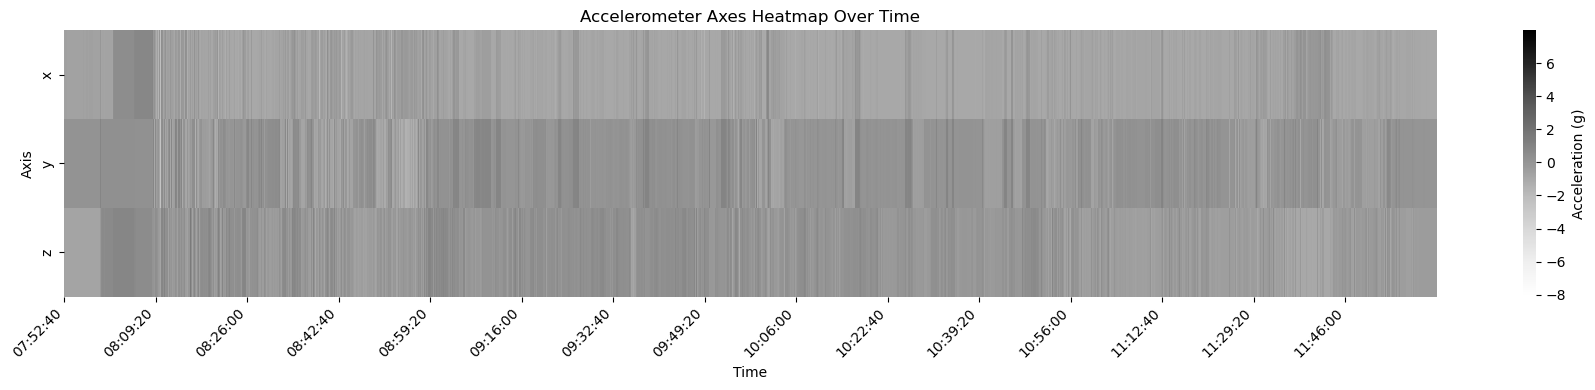

In [33]:
accel_data.columns = pd.to_datetime(accel_data.columns, format='%H:%M:%S.%f')

plt.figure(figsize=(18, 4))
sns.heatmap(accel_data, cmap='Greys', cbar_kws={'label': 'Acceleration (g)'})
plt.title("Accelerometer Axes Heatmap Over Time")
plt.xlabel("Time")
plt.ylabel("Axis")

# Plot fewer xticks (e.g. every 20,000th column if you have a lot of timepoints)
step = 50000
xticks = np.arange(0, accel_data.shape[1], step)
xtick_labels = accel_data.columns[xticks].strftime('%H:%M:%S')

plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

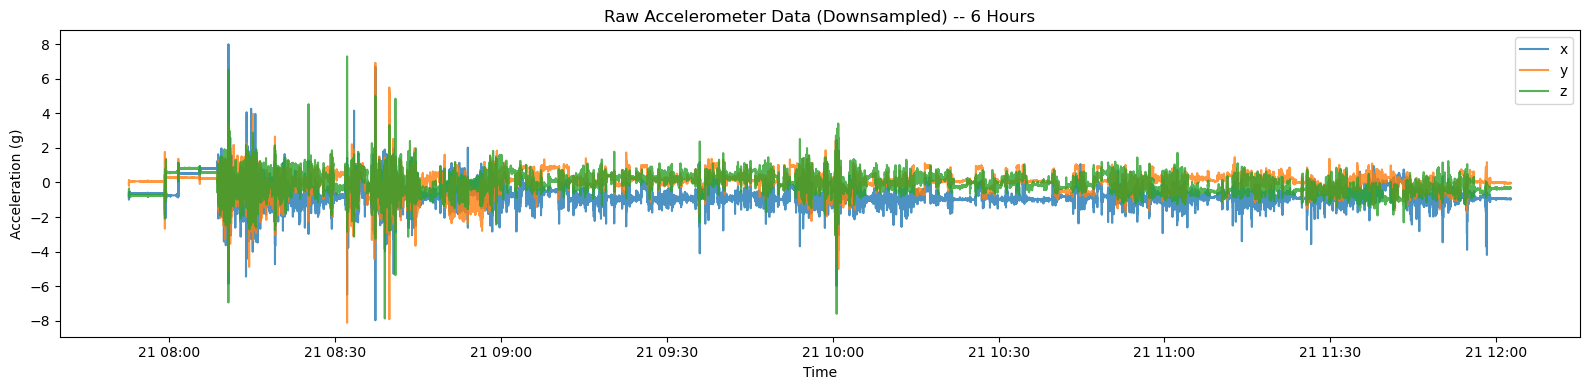

In [34]:
plt.figure(figsize=(16, 4))
for axis in ['x', 'y', 'z']:
    plt.plot(subset_subsampled['time'], subset_subsampled[axis], label=axis, alpha=0.8)

plt.title('Raw Accelerometer Data (Downsampled) -- 6 Hours')
plt.xlabel('Time')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
subset_subsampled.head()

,time,x,y,z,annotation,activity_id,activity_raw,activity,MET
2500000,2016-10-21 07:52:40.000,-0.792484,-0.043302,-0.616524,None,NaN,NaN,NaN,NaN
2500002,2016-10-21 07:52:40.020,-0.776872,-0.075037,-0.664463,None,NaN,NaN,NaN,NaN
2500004,2016-10-21 07:52:40.040,-0.745650,-0.059169,-0.696423,None,NaN,NaN,NaN,NaN
2500006,2016-10-21 07:52:40.060,-0.761261,-0.106772,-0.632504,None,NaN,NaN,NaN,NaN
2500008,2016-10-21 07:52:40.080,-0.792484,-0.106772,-0.648483,None,NaN,NaN,NaN,NaN


In [36]:
subset_subsampled.shape

(750000, 9)

In [37]:
def butter_bandpass_filter(data, lowcut=0.25, highcut=10, fs=50, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Apply to x, y, z
subset_subsampled['x_filt'] = butter_bandpass_filter(subset_subsampled['x'].values)
subset_subsampled['y_filt'] = butter_bandpass_filter(subset_subsampled['y'].values)
subset_subsampled['z_filt'] = butter_bandpass_filter(subset_subsampled['z'].values)

/tmp/ipykernel_3737302/2339272507.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_subsampled['x_filt'] = butter_bandpass_filter(subset_subsampled['x'].values)
/tmp/ipykernel_3737302/2339272507.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_subsampled['y_filt'] = butter_bandpass_filter(subset_subsampled['y'].values)
/tmp/ipykernel_3737302/2339272507.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

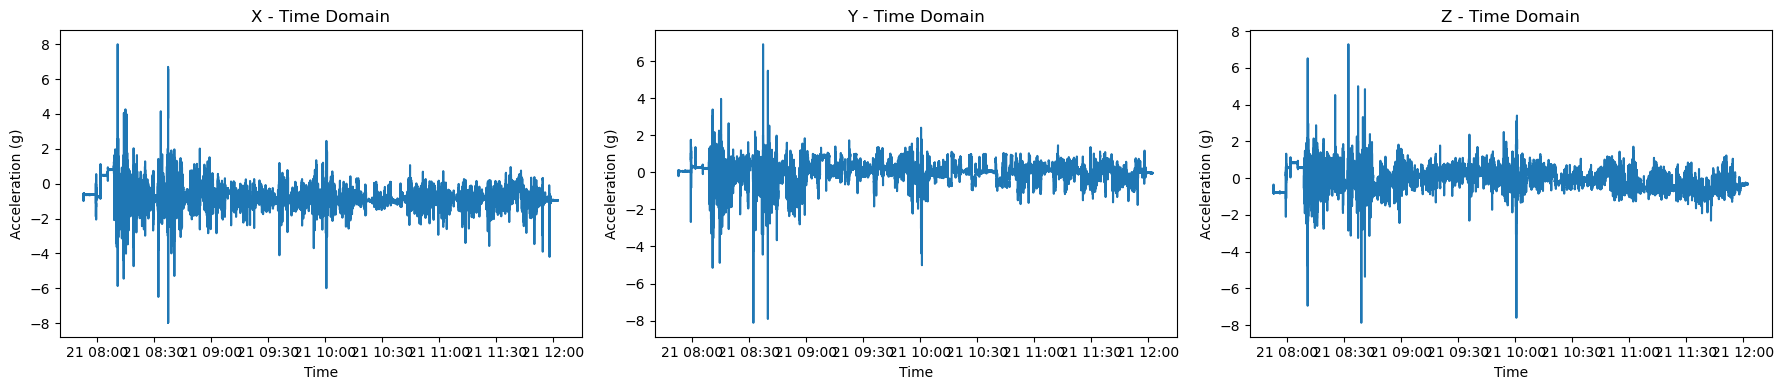

In [38]:
# Ensure time column is in datetime and sorted
subset_subsampled = subset_subsampled.sort_values('time')
times = pd.to_datetime(subset_subsampled['time'])

# Prepare figure with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
axes = ['x', 'y', 'z']

for i, axis in enumerate(axes):
    signal = subset_subsampled[axis].values

    axs[i].plot(times, signal)
    axs[i].set_title(f'{axis.upper()} - Time Domain')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Acceleration (g)')

plt.tight_layout()
plt.show()

In [39]:
subset_subsampled.shape

(750000, 12)

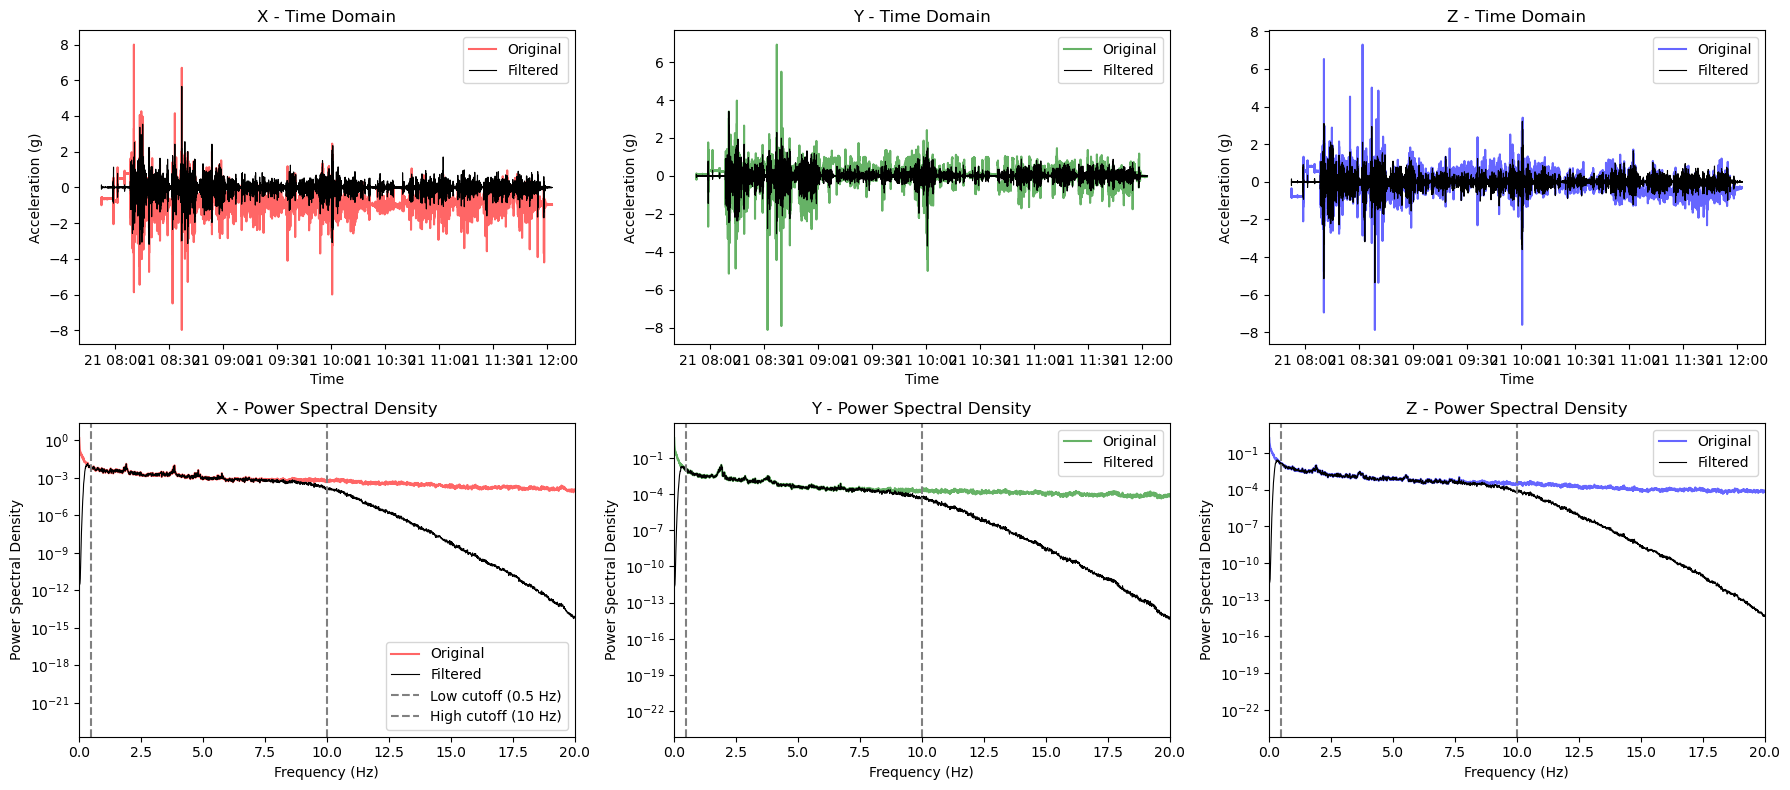

In [40]:
fs = 50  # Hz
times = pd.to_datetime(subset_subsampled['time'])
axes = ['x', 'y', 'z']
colors = {'x': 'red', 'y': 'green', 'z': 'blue'}

fig, axs = plt.subplots(2, 3, figsize=(18, 8))

for i, axis in enumerate(axes):
    original = subset_subsampled[axis].values
    filtered = subset_subsampled[f'{axis}_filt'].values

    # Time Domain Plot
    axs[0, i].plot(times, original, label='Original', color=colors[axis], alpha=0.6)
    axs[0, i].plot(times, filtered, label='Filtered', color='black', linewidth=0.8)
    axs[0, i].set_title(f"{axis.upper()} - Time Domain")
    axs[0, i].set_xlabel("Time")
    axs[0, i].set_ylabel("Acceleration (g)")
    axs[0, i].legend()

    # PSD Plot
    f_orig, Pxx_orig = welch(original, fs=fs, nperseg=8192)
    f_filt, Pxx_filt = welch(filtered, fs=fs, nperseg=8192)

    axs[1, i].semilogy(f_orig, Pxx_orig, label='Original', color=colors[axis], alpha=0.6)
    axs[1, i].semilogy(f_filt, Pxx_filt, label='Filtered', color='black', linewidth=0.8)
    axs[1, i].axvline(0.5, color='gray', linestyle='--', label='Low cutoff (0.5 Hz)' if i == 0 else "")
    axs[1, i].axvline(10, color='gray', linestyle='--', label='High cutoff (10 Hz)' if i == 0 else "")
    axs[1, i].set_title(f"{axis.upper()} - Power Spectral Density")
    axs[1, i].set_xlabel("Frequency (Hz)")
    axs[1, i].set_ylabel("Power Spectral Density")
    axs[1, i].set_xlim([0, 20])
    axs[1, i].legend()

plt.tight_layout()
plt.show()

In [41]:
largest = max(
    ((os.path.join(dp, f), os.path.getsize(os.path.join(dp, f)))
     for dp, _, filenames in os.walk(parquet_folder) for f in filenames),
    key=lambda x: x[1]
)

print(f"Largest file: {largest[0]} ({largest[1] / 1e6:.2f} MB)")

Largest file: /scratch/besp/shared_data/capture24/capture24_parquets/P100.parquet (76.77 MB)


In [42]:
file_path = os.path.join(parquet_folder, 'P100.parquet')

start = time.time()
ddf = dd.read_parquet(file_path)
end = time.time()

print(f"Read time: {end - start:.2f} seconds")

Read time: 0.04 seconds


In [47]:
total_size = 0
largest = ("", 0)

for dp, _, filenames in os.walk(parquet_folder):
    for f in filenames:
        file_path = os.path.join(dp, f)
        size = os.path.getsize(file_path)
        total_size += size
        if size > largest[1]:
            largest = (file_path, size)

print(f"Total size: {total_size / 1e9:.2f} GB")
print(f"Largest file: {largest[0]} ({largest[1] / 1e6:.2f} MB)")

Total size: 9.64 GB
Largest file: /scratch/besp/shared_data/capture24/capture24_parquets/P100.parquet (76.77 MB)
